## Imports

In [169]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

## Extracting the data

In [183]:
# Load the dataset, specifying the semicolon as a delimiter
df = pd.read_csv('/content/data.csv', delimiter=';')

## Data Analysis

In [170]:
# Display the first 5 rows of the DataFrame
display(df.head())

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [171]:
# Display DataFrame information (e.g., data types, non-null values)
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification  

In [172]:
# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [173]:
# Check for missing values in each column
print("\nMissing values per column:")
display(df.isnull().sum())


Missing values per column:


,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance\t,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


### Visualizing Class Imbalances in Categorical Features

In [174]:
# Rename the column
df = df.rename(columns={'Daytime/evening attendance\t': 'Daytime/evening attendance'})

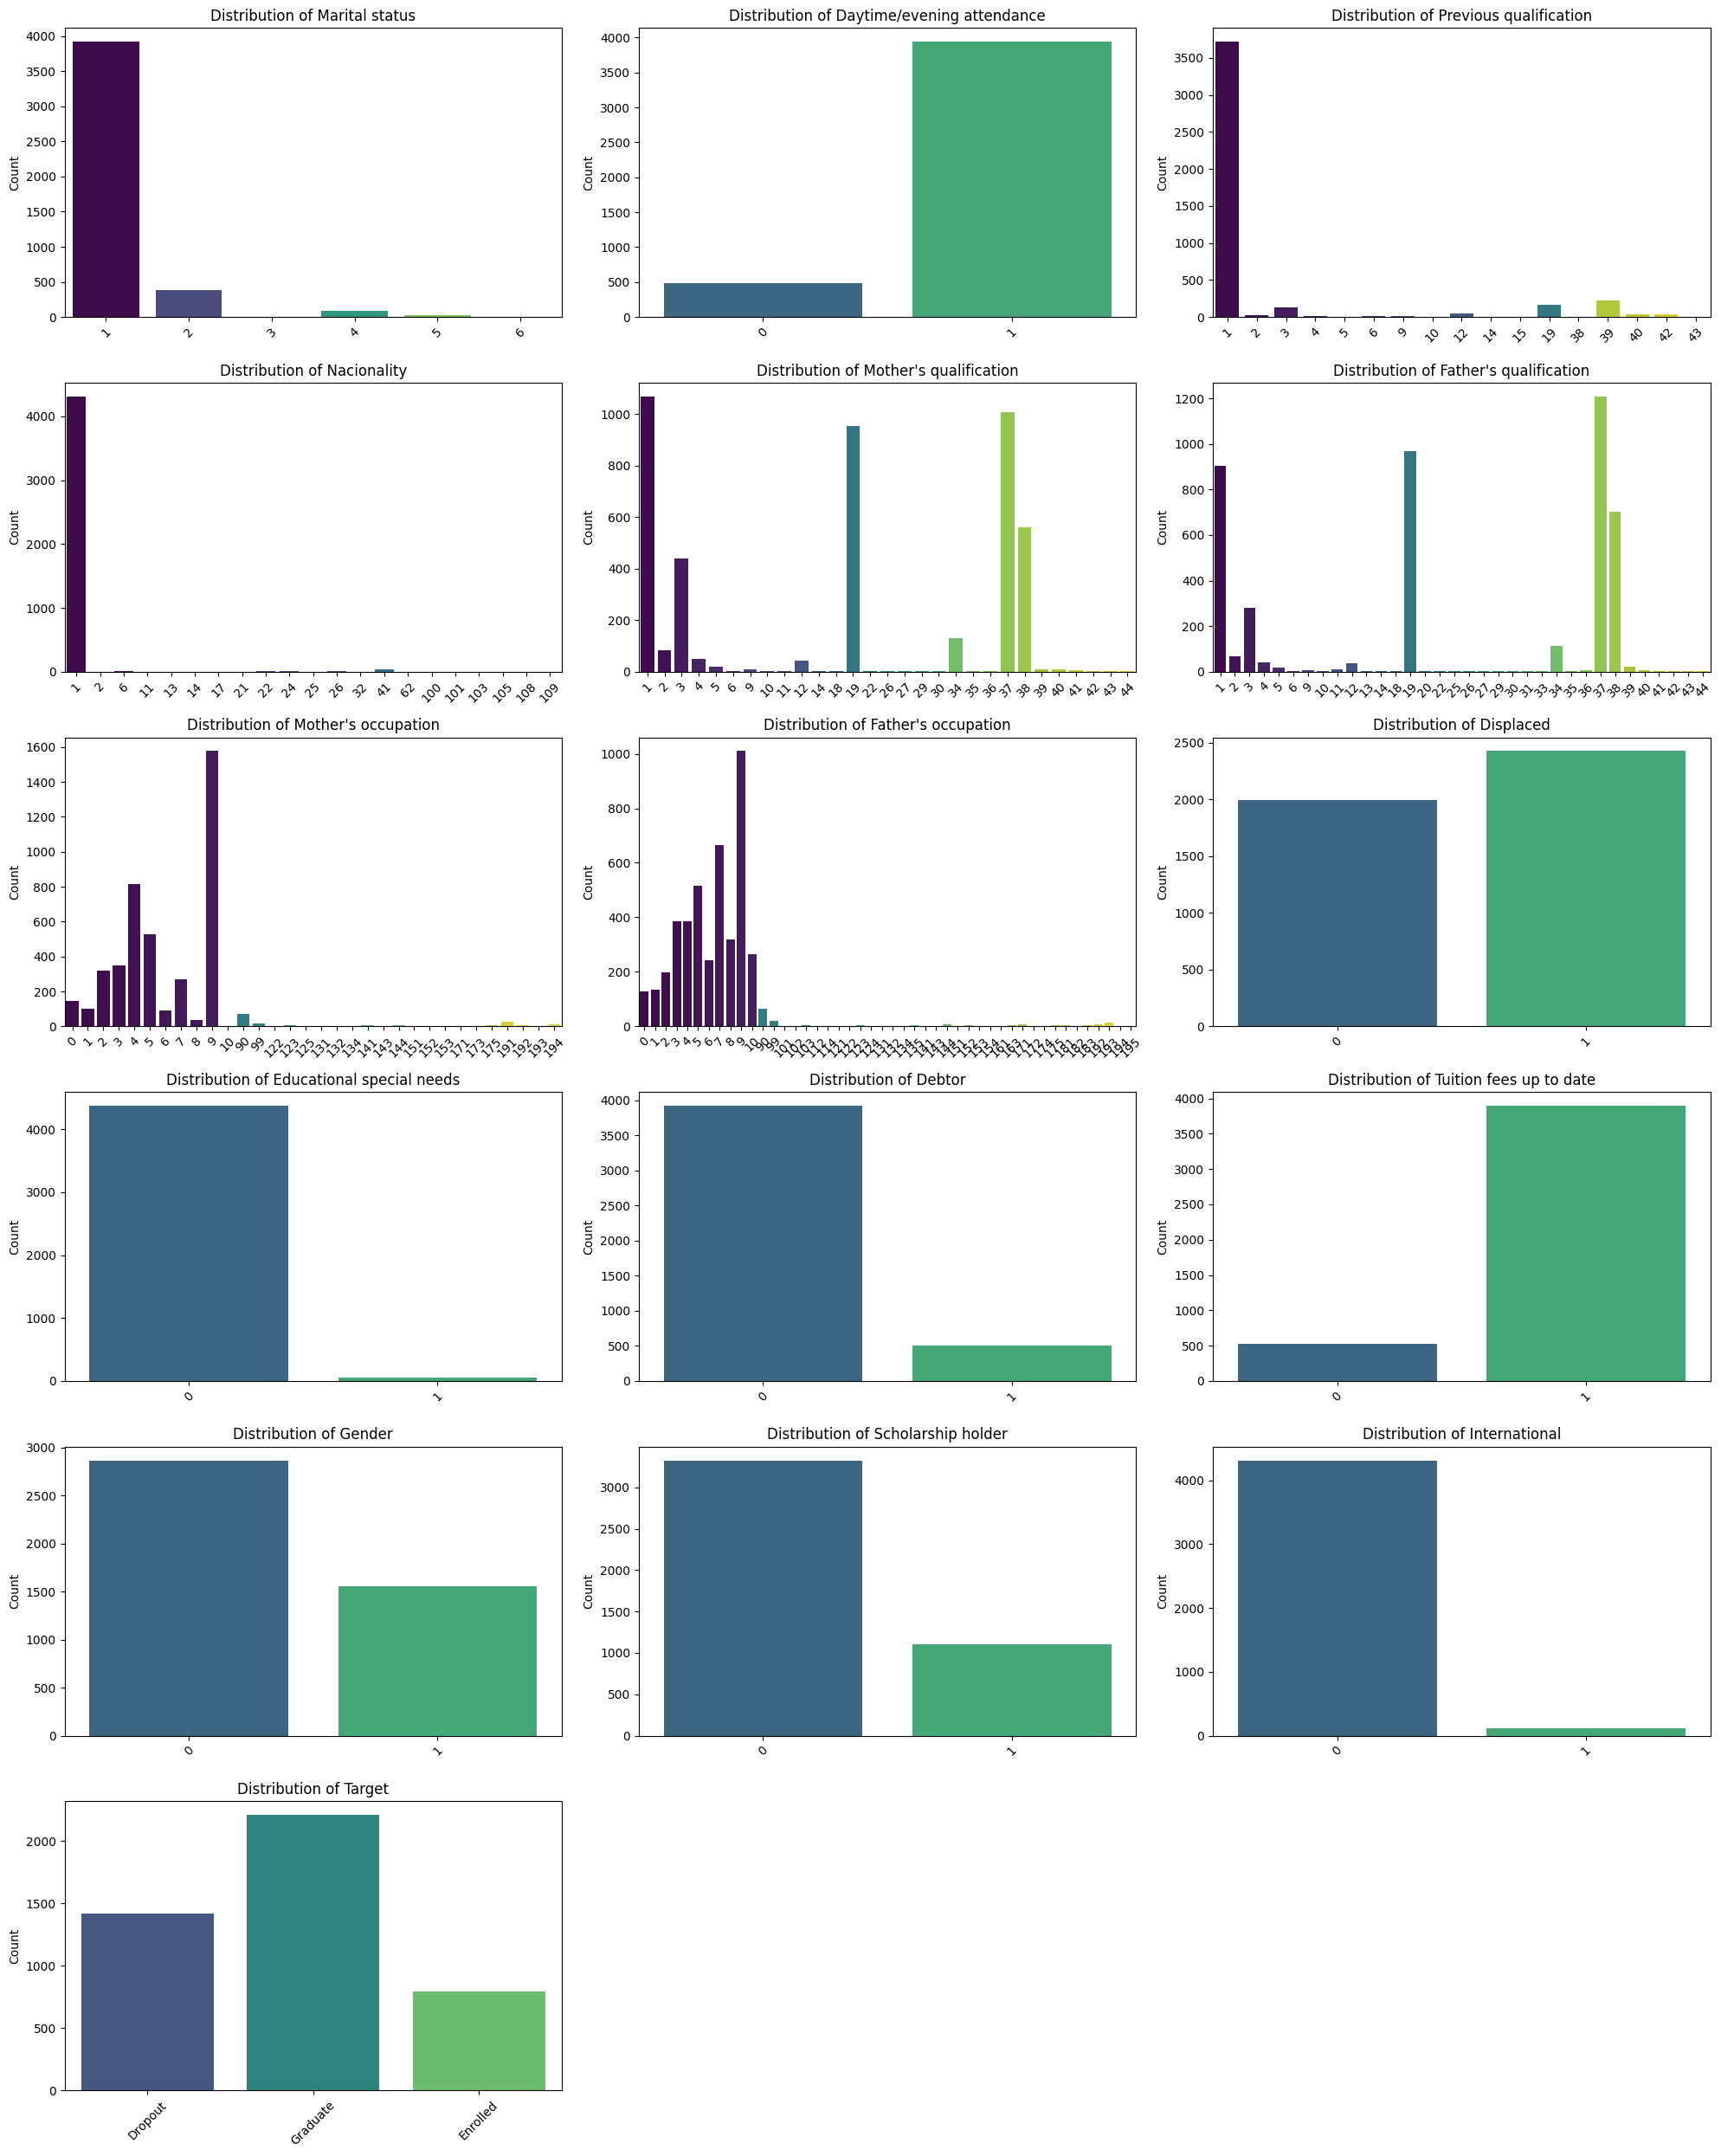

In [175]:
# List categorical columns for plotting
categorical_cols = [
    'Marital status',
    'Daytime/evening attendance',
    'Previous qualification',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International',
    'Target'
]

# Set up the figure and axes for plotting
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(20, 25))
axes = axes.flatten()

# Loop through each categorical column and plot its distribution
for i, col in enumerate(categorical_cols):
    if i < len(axes):
        sns.countplot(x=col, data=df, ax=axes[i], palette='viridis', hue=col, legend=False)
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45) # Rotate x-axis labels

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### Visualizing Numerical Feature Distributions

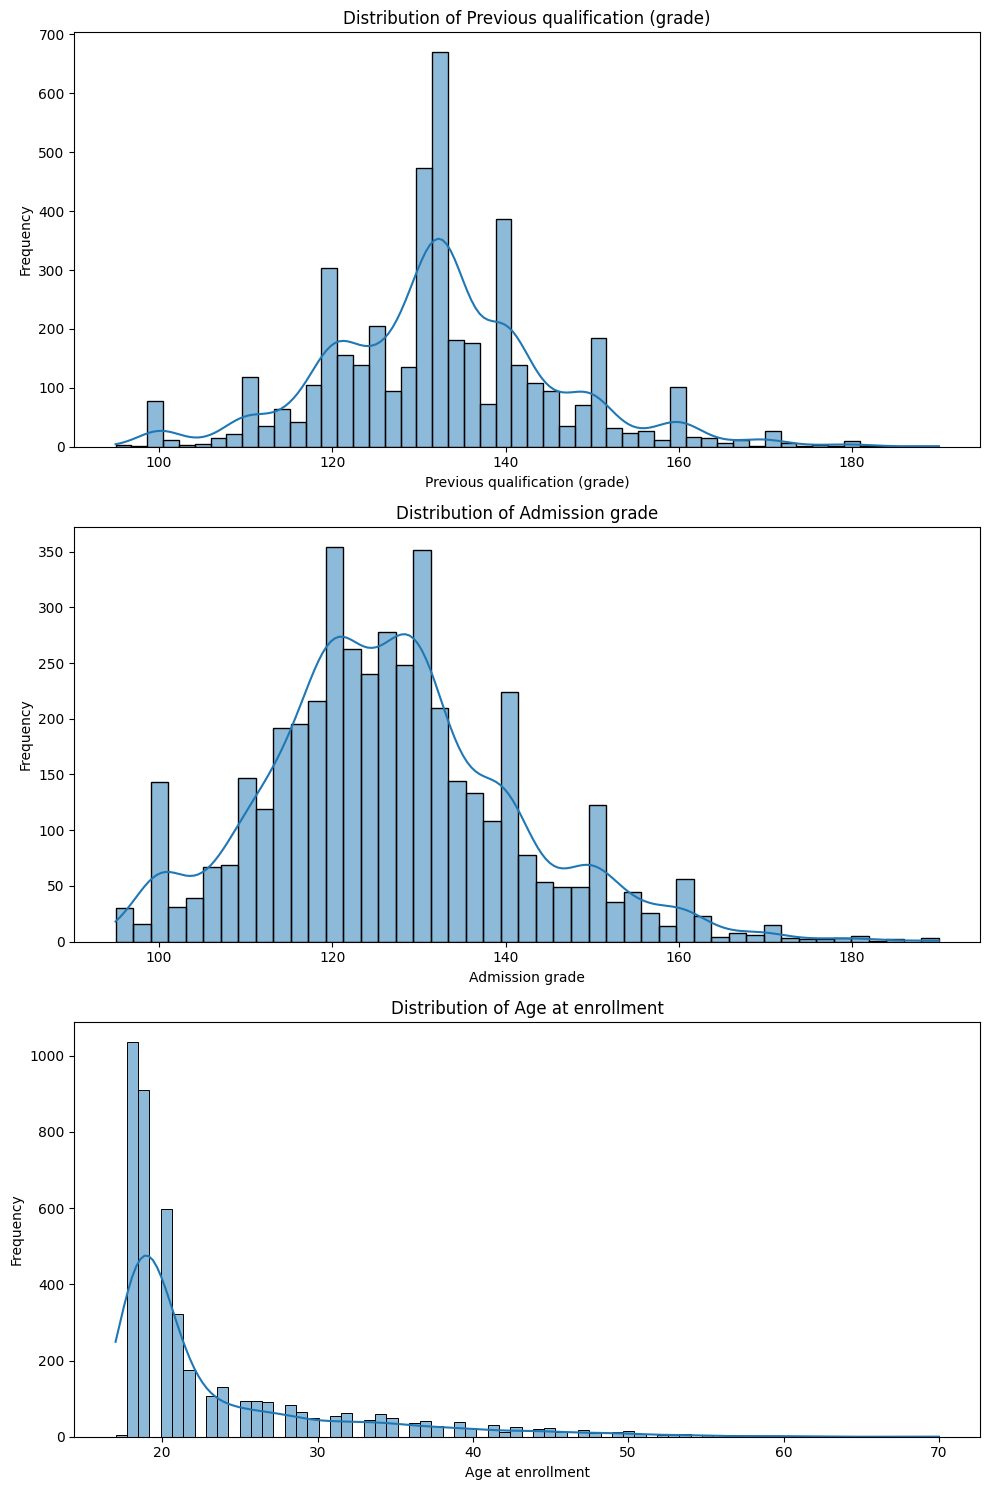

In [176]:
# Identify numerical columns for plotting (continuous/ordinal numerical features)
numerical_cols = [
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment'
]

# Set up the figure and axes for plotting histograms
num_numerical_cols = len(numerical_cols)
fig, axes = plt.subplots(nrows=num_numerical_cols, ncols=1, figsize=(10, 5 * num_numerical_cols))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    # Histogram for distribution
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout(); # Adjust layout to prevent overlapping titles/labels
plt.show()

### Correlation Matrix and Highly Correlated Features

*The correlation matrix plotting and highly correlated feature detection functions in this section were adapted from the GitHub repository **MushroomClassification** by GitHub user **@alejandraa-cruiz.***
https://github.com/alejandraa-cruiz/MushroomClassification

In [177]:
def plot_correlation_matrix(df):
  """Plots a correlation heatmap for the given DataFrame."""
  correlation_matrix = df.corr(numeric_only=True)
  plt.figure(figsize=(12, 10))
  sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
  plt.title('Correlation Heatmap')
  plt.show()
  return correlation_matrix

In [178]:
def high_correlation_features(correlation_matrix, threshold):
  # Calculate the absolute values of the correlation matrix
  corr_matrix_abs = correlation_matrix.abs()

  # Select the upper triangle of the absolute correlation matrix to avoid duplicate pairs and self-correlation
  upper_triangle = corr_matrix_abs.where(
      np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool)
  )

  # Unstack the upper triangle to get a Series of feature pairs and their correlations, then drop NaN values
  high_corr = upper_triangle.unstack().dropna()
  # Filter for correlations above the specified threshold and sort in descending order
  high_corr = high_corr[high_corr > threshold].sort_values(ascending=False)

  print(f"Highly correlated feature pairs above {threshold}:\n{high_corr}")

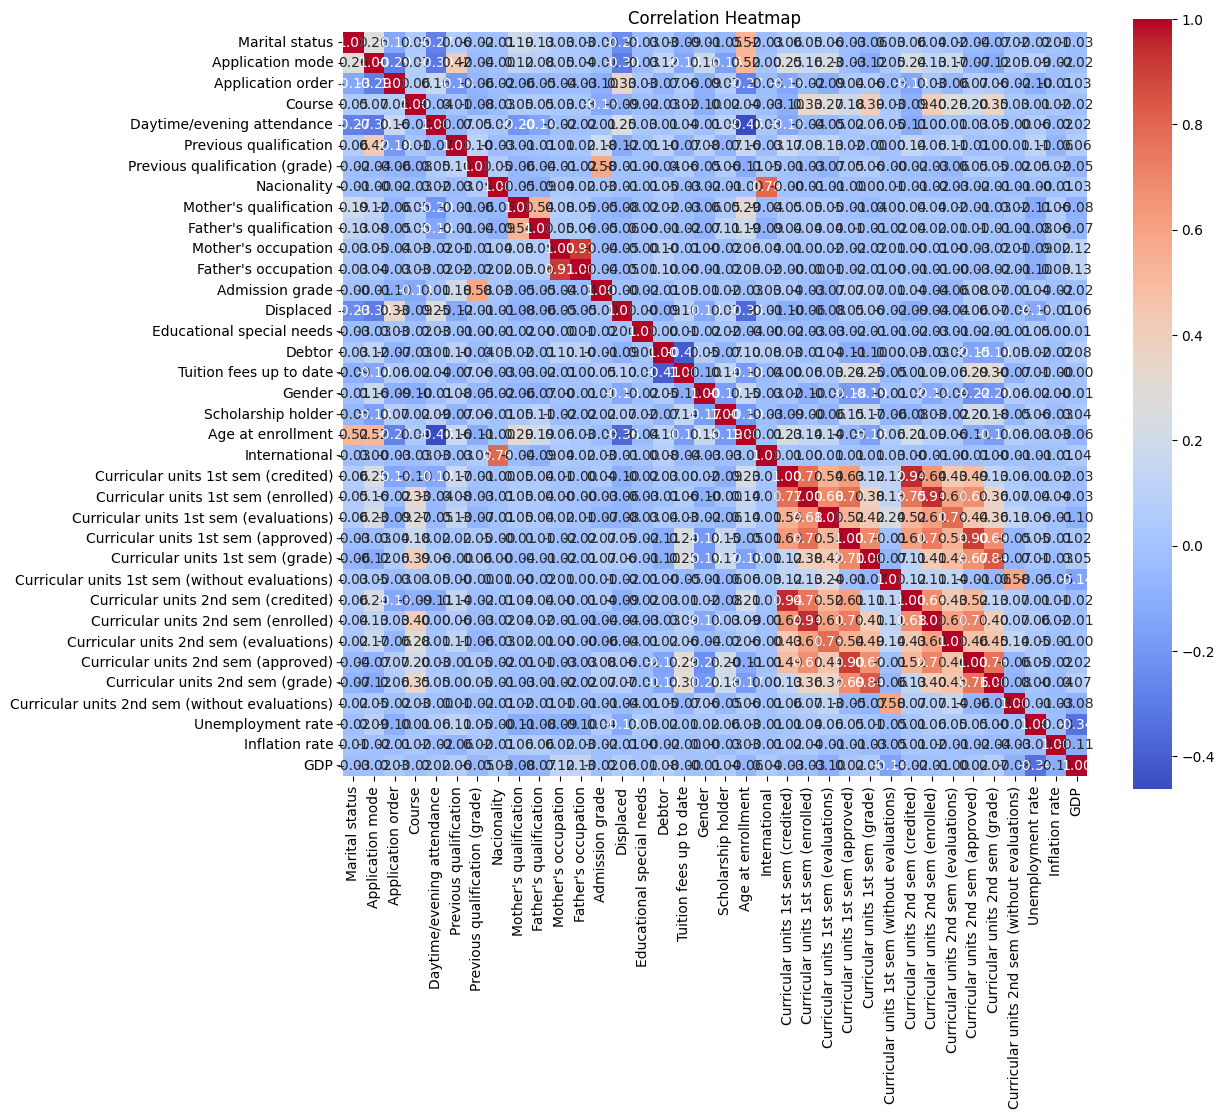

Highly correlated feature pairs above 0.65:
Curricular units 2nd sem (credited)     Curricular units 1st sem (credited)       0.944811
Curricular units 2nd sem (enrolled)     Curricular units 1st sem (enrolled)       0.942627
Father's occupation                     Mother's occupation                       0.910472
Curricular units 2nd sem (approved)     Curricular units 1st sem (approved)       0.904002
Curricular units 2nd sem (grade)        Curricular units 1st sem (grade)          0.837170
International                           Nacionality                               0.790935
Curricular units 2nd sem (evaluations)  Curricular units 1st sem (evaluations)    0.778863
Curricular units 1st sem (enrolled)     Curricular units 1st sem (credited)       0.774344
Curricular units 1st sem (approved)     Curricular units 1st sem (enrolled)       0.769083
Curricular units 2nd sem (grade)        Curricular units 2nd sem (approved)       0.760804
Curricular units 2nd sem (credited)     Curric

In [179]:
# Calculate and plot the correlation matrix
correlation_matrix = plot_correlation_matrix(df)

# Define a threshold for high correlation
threshold = 0.65

# Identify and print highly correlated features
high_correlation_features(correlation_matrix, threshold)

## Preprocessing

In [184]:
# List of columns to drop
columns_to_drop = [
    'Application mode',
    'Application order',
    'Course',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Nacionality',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

# Drop the specified columns
df = df.drop(columns=columns_to_drop)

In [185]:
# Drop rows where 'Target' is 'Enrolled'
df = df[df['Target'] != 'Enrolled']

# Get the value counts of the 'Target' column after removal
target_counts = df['Target'].value_counts()

print("\nDistribution of the 'Target' variable:")
display(target_counts)


Distribution of the 'Target' variable:


,count
Target,
Graduate,2209
Dropout,1421


### Simplified Correlation Matrix After Features Selection

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


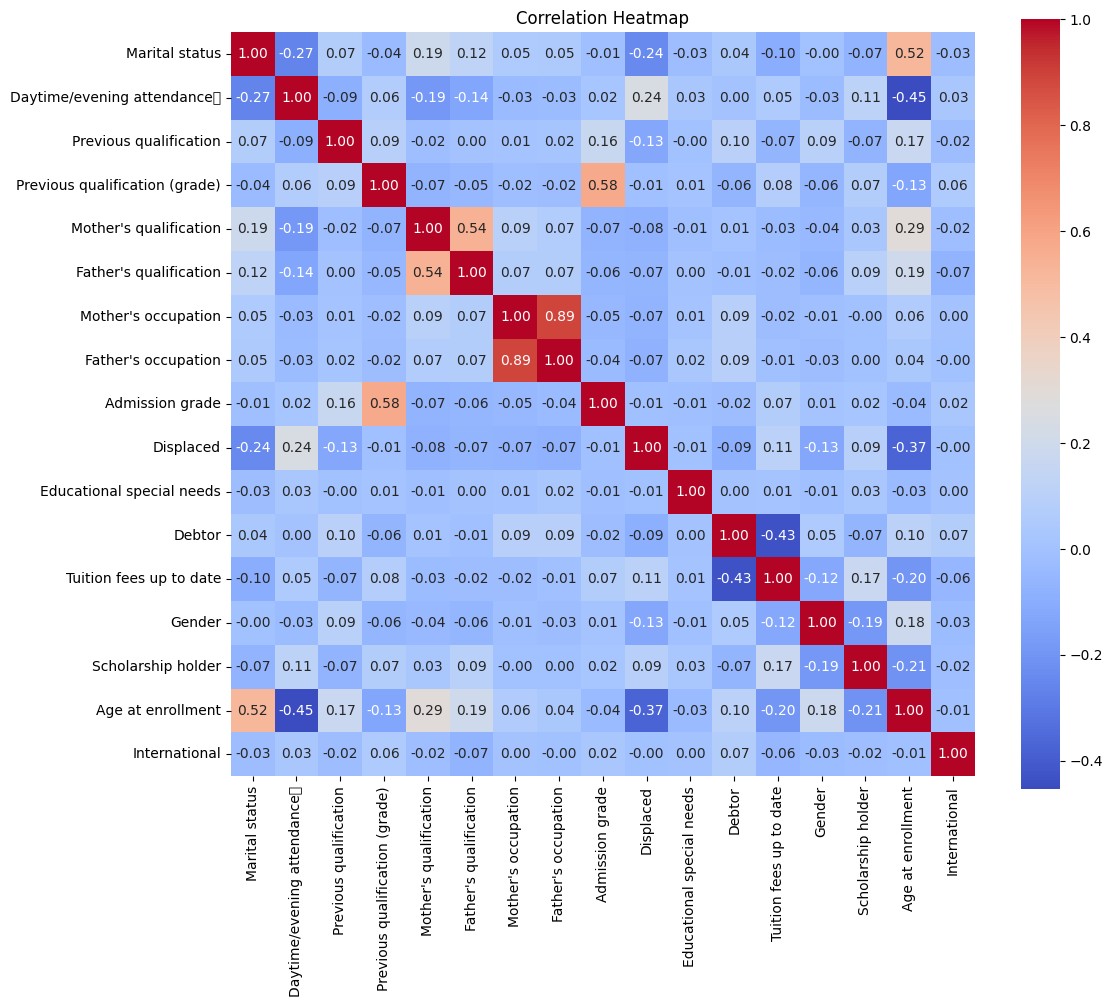

Highly correlated feature pairs above 0.65:
Father's occupation  Mother's occupation    0.886568
dtype: float64


In [186]:
# Calculate and plot the correlation matrix
correlation_matrix = plot_correlation_matrix(df)

# Define a threshold for high correlation
threshold = 0.65

# Identify and print highly correlated features
high_correlation_features(correlation_matrix, threshold)

### Encoding of 'Target' Attribute

In [187]:
# Store the meaning of the target values
target_mapping = {
    'Graduate': 0,
    'Dropout': 1
}

target_names = {
    0: 'Graduate',
    1: 'Dropout'
}

# Create y from the Target column, already mapped
y_encoded = df['Target'].map(target_mapping)

## Split

In [188]:
# Separate features (X) from the target variable
X = df.drop(columns=['Target'])

# Split the data into training and testing sets
X_train, X_test, y_encoded_train, y_encoded_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_encoded_train:", y_encoded_train.shape)
print("Shape of y_encoded_test:", y_encoded_test.shape)


Shape of X_train: (2904, 17)
Shape of X_test: (726, 17)
Shape of y_encoded_train: (2904,)
Shape of y_encoded_test: (726,)


### Scaling The Continous Features

In [189]:
continuous_features = [
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment'
]

categorical_features = [col for col in X_train.columns if col not in continuous_features]

# Separate continuous and categorical features for training set
X_train_continuous = X_train[continuous_features]
X_train_categorical = X_train[categorical_features]

# Separate continuous and categorical features for test set
X_test_continuous = X_test[continuous_features]
X_test_categorical = X_test[categorical_features]

In [190]:
scaler = StandardScaler()

# Fit and transform the continuous features of the training set
X_train_continuous_scaled = scaler.fit_transform(X_train_continuous)

# Transform the continuous features of the test set
X_test_continuous_scaled = scaler.transform(X_test_continuous)

# Convert scaled arrays back to DataFrames with original column names
X_train_continuous_scaled_df = pd.DataFrame(X_train_continuous_scaled, columns=continuous_features, index=X_train_continuous.index)
X_test_continuous_scaled_df = pd.DataFrame(X_test_continuous_scaled, columns=continuous_features, index=X_test_continuous.index)

# Concatenate scaled continuous features with unscaled categorical features
# Ensure the order of columns is consistent with the original X
X_train_scaled = pd.concat([
    X_train_continuous_scaled_df,
    X_train_categorical
], axis=1)[X_train.columns]

X_test_scaled = pd.concat([
    X_test_continuous_scaled_df,
    X_test_categorical
], axis=1)[X_test.columns]

print("\nShape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)


Shape of X_train_scaled: (2904, 17)
Shape of X_test_scaled: (726, 17)


## Model Evaluation Functions

In [191]:
def plot_training_history(history):
  """Plots the training and validation accuracy and loss over epochs."""
  fig, axes = plt.subplots(1, 2, figsize=(15, 5))

  # Plot accuracy
  axes[0].plot(history.history['accuracy'], label='Training Accuracy')
  axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
  axes[0].set_title('Model Accuracy')
  axes[0].set_xlabel('Epoch')
  axes[0].set_ylabel('Accuracy')
  axes[0].legend()
  axes[0].grid(True)

  # Plot loss
  axes[1].plot(history.history['loss'], label='Training Loss')
  axes[1].plot(history.history['val_loss'], label='Validation Loss')
  axes[1].set_title('Model Loss')
  axes[1].set_xlabel('Epoch')
  axes[1].set_ylabel('Loss')
  axes[1].legend()
  axes[1].grid(True)

  plt.tight_layout()
  plt.show()

### Evaluation

*The confusion matrix plotting and evaluation in this section were adapted from the GitHub repository **MushroomClassification** by GitHub user **@alejandraa-cruiz.***
https://github.com/alejandraa-cruiz/MushroomClassification

In [192]:
def evaluate_model(model, X_test_scaled, y_encoded_test, target_names, prediction_threshold=0.5):
  """Evaluates the given model and displays a classification report and confusion matrix, and AUC score."""
  # Make predictions on the test set (probabilities)
  predictions = model.predict(X_test_scaled)

  # Convert probabilities to binary class labels (0 or 1) using the specified threshold
  predicted_classes = (predictions > prediction_threshold).astype(int).flatten()

  # True class labels are already label-encoded
  true_classes = y_encoded_test

  print("\nClassification Report:")
  print(classification_report(true_classes, predicted_classes, target_names=list(target_names.values())))

  # Calculate and print AUC score
  auc_score = roc_auc_score(true_classes, predictions)
  print(f"\nAUC Score: {auc_score:.4f}")

  cm = confusion_matrix(true_classes, predicted_classes)

  # Visualize the confusion matrix
  labels = list(target_names.values())
  fig, axes = plt.subplots(1, 2, figsize=(16, 6))

  # Plot Confusion Matrix
  display_matrix = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
  display_matrix.plot(cmap='Blues', ax=axes[0])
  axes[0].set_title(f'Confusion Matrix (Threshold: {prediction_threshold})')

  # Plot ROC curve
  fpr, tpr, thresholds = roc_curve(true_classes, predictions)
  axes[1].plot(fpr, tpr, color='orange', label=f'ROC Curve (AUC = {auc_score:.2f})')
  axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
  axes[1].set_xlabel('False Positive Rate')
  axes[1].set_ylabel('True Positive Rate')
  axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
  axes[1].legend()
  axes[1].grid(True)

  plt.tight_layout()
  plt.show()

## Initial Model

### Logistic Regression Model

In [197]:
# Define the Keras model for binary classification
LRModel = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model with binary_crossentropy loss
LRModel.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display the model summary
LRModel.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 1)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18 (72.00 B)

 Trainable params: 18 (72.00 B)

 Non-trainable params: 0 (0.00 B)

In [207]:
# Train the model
LRHistory = LRModel.fit(
    X_train_scaled, y_encoded_train, # Use y_encoded_train for binary_crossentropy
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=0 # Set to 1 to see progress
)

# Evaluate the model on the test set
loss, accuracy = LRModel.evaluate(X_test_scaled, y_encoded_test, verbose=0) # Evaluate on X_test and y_encoded_test
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.4905
Test Accuracy: 0.7562


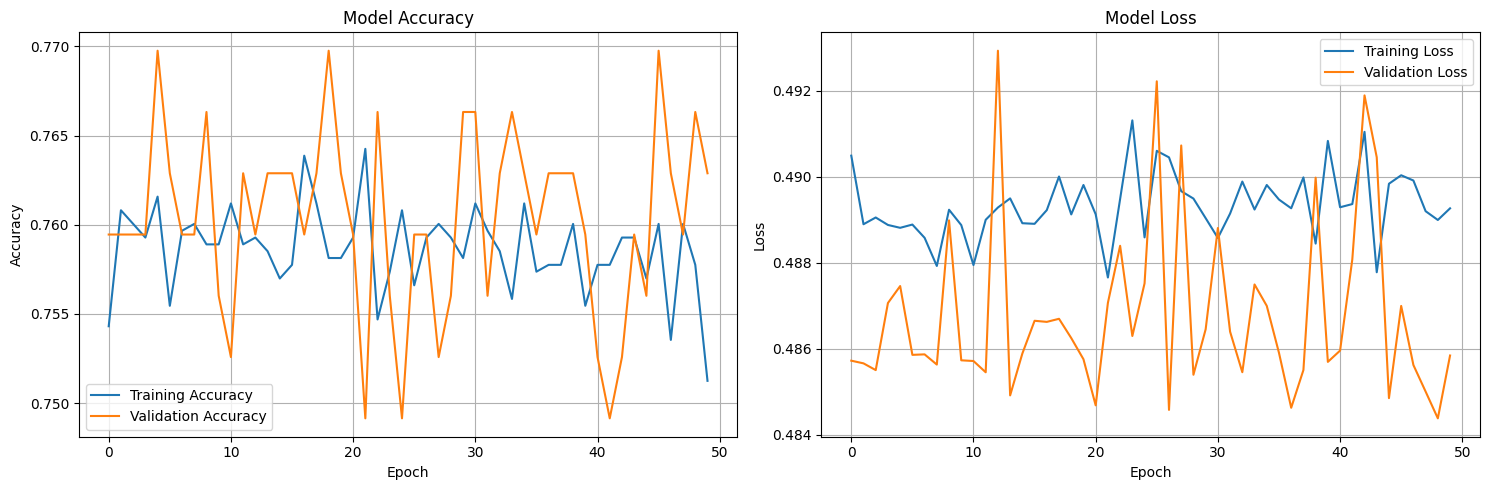

In [208]:
# Call the function to plot the training history
plot_training_history(LRHistory)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Classification Report:
              precision    recall  f1-score   support

    Graduate       0.83      0.70      0.76       442
     Dropout       0.63      0.78      0.70       284

    accuracy                           0.73       726
   macro avg       0.73      0.74      0.73       726
weighted avg       0.75      0.73      0.74       726


AUC Score: 0.8173


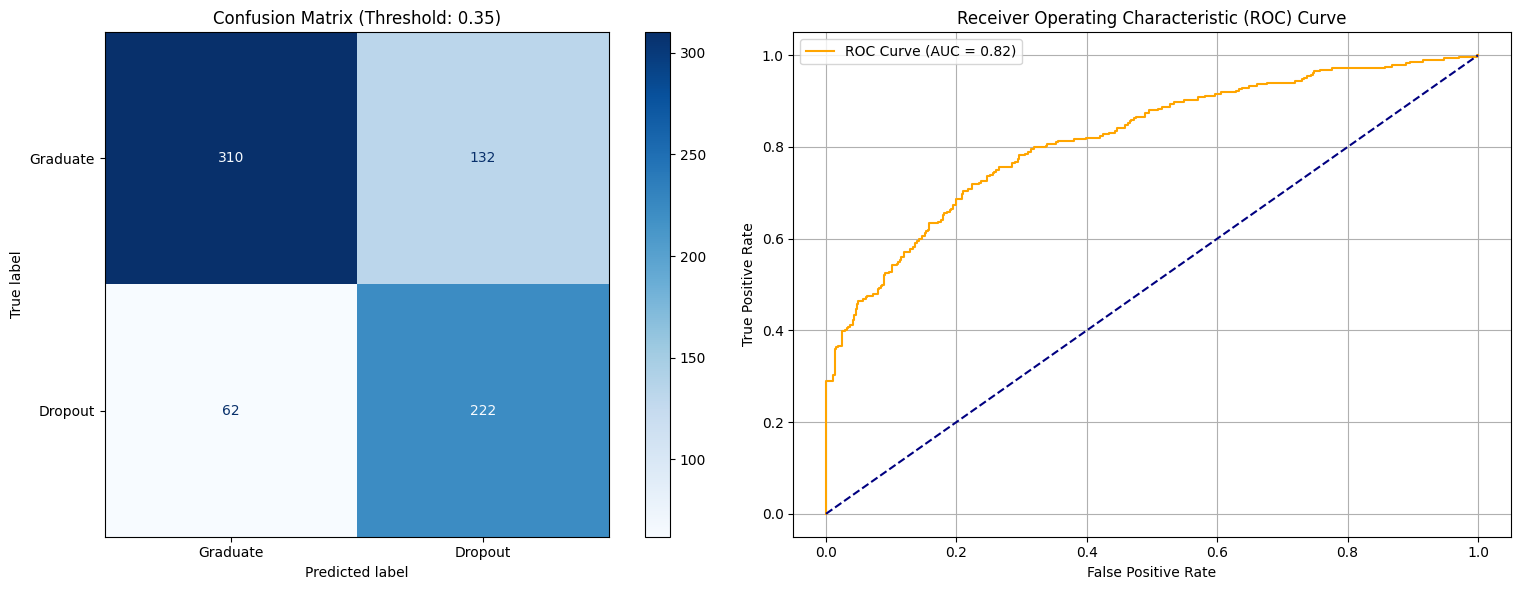

In [209]:
# Call the function to evaluate the model
evaluate_model(LRModel, X_test_scaled, y_encoded_test, target_names, prediction_threshold=0.35)